In [31]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


from sklearn.metrics import (accuracy_score , f1_score , classification_report , confusion_matrix , roc_auc_score , roc_curve , auc)

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import joblib
import numpy as np


# Load ANN
ann_model = load_model("../artifacts/models/ANN_6_layers.h5")  # or .keras

# Load XGB
# xgb_model = joblib.load("../artifacts/models/xgb.joblib")

# Load your test data
X , y = np.load("../data/processed/data_matrix2_reduced.npy") , np.load("../data/processed/y.npy")
y = np.where(y>=4,1,0)

xtrain , xtest , ytrain , ytest = train_test_split(X,y , random_state=42 , test_size = 0.1 ,stratify = y)




In [34]:
print(xtest.shape)
print(ytest.shape)

(8585, 92)
(8585,)


In [35]:
y_pred_ann_proba = ann_model.predict(xtest)
# y_pred_ann = np.argmax(y_pred_ann_proba)
y_pred_ann_proba

269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.5012207],
       [0.5012207],
       [0.5012207],
       ...,
       [0.5012207],
       [0.5012207],
       [0.5012207]], shape=(8585, 1), dtype=float32)

In [36]:
np.unique(ytest)

array([0, 1])

In [37]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.0, 1.0, 0.01)
scores = []

for t in thresholds:
    labels = (y_pred_ann_proba >= t).astype(int)
    labels = np.argmax(y_pred_ann_proba, axis=1)
    scores.append(f1_score(ytest, labels))

best_threshold = thresholds[np.argmax(scores)]
print(f"Best threshold: {best_threshold}")


Best threshold: 0.0


In [17]:
from sklearn.metrics import recall_score , precision_score

In [38]:
# Accuracy and F1 score
y_pred_ann = (y_pred_ann_proba >= 0.5).astype(int)
print("ANN accuracy :" ,accuracy_score(ytest , y_pred_ann))
print("ANN F1-score  :" , f1_score(ytest , y_pred_ann,average = "weighted")  )
print("ANN recall  :" , recall_score(ytest , y_pred_ann)  )
print("ANN precision  :" , precision_score(ytest , y_pred_ann)  )

ANN accuracy : 0.8246942341292953
ANN F1-score  : 0.7454625186894875
ANN recall  : 1.0
ANN precision  : 0.8246942341292953


In [19]:
# =====================================================
# 6. Classification Reports
# =====================================================
print("=== ANN Classification Report ===")
print(classification_report(ytest, y_pred_ann))




=== ANN Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1505
           1       0.82      1.00      0.90      7080

    accuracy                           0.82      8585
   macro avg       0.41      0.50      0.45      8585
weighted avg       0.68      0.82      0.75      8585



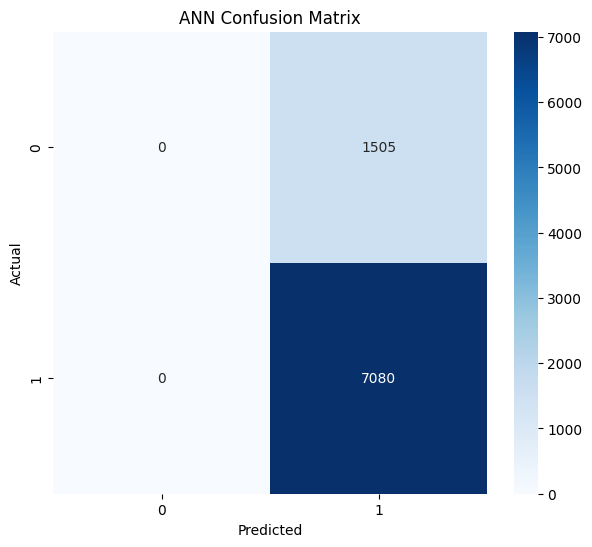

In [22]:

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_ann)

fig, ax = plt.subplots(figsize=(7,6))  # just one subplot
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)

ax.set_title("ANN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.show()



(8585, 92)
(8585,)
269/269 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Best threshold: 0.23
ANN accuracy : 0.8514851485148515
ANN F1-score  : 0.8189803982458491
ANN recall  : 0.9812146892655367
ANN precision  : 0.8588206205958709
=== ANN Classification Report ===
              precision    recall  f1-score   support

           0       0.73      0.24      0.36      1505
           1       0.86      0.98      0.92      7080

    accuracy                           0.85      8585
   macro avg       0.80      0.61      0.64      8585
weighted avg       0.84      0.85      0.82      8585



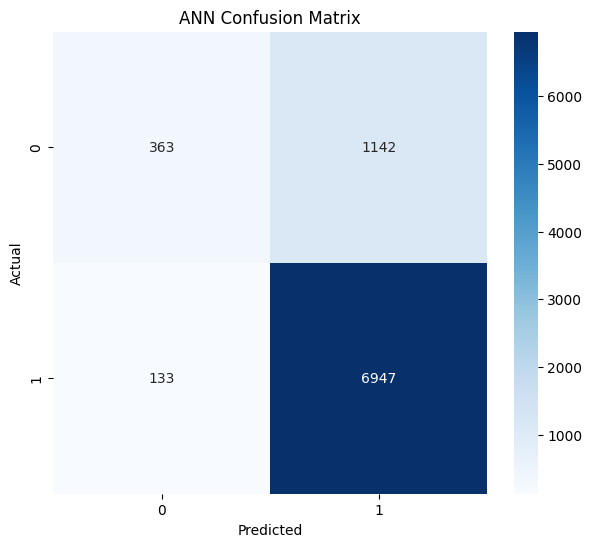

In [5]:
# %%
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


from sklearn.metrics import (accuracy_score , f1_score , classification_report , confusion_matrix , roc_auc_score , roc_curve , auc)

# %%
import warnings
warnings.filterwarnings('ignore')

# %%
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import joblib
import numpy as np


# Load ANN
ann_model = load_model("../artifacts/models/ANN_4_layers_2.h5")  # or .keras

# Load XGB
# xgb_model = joblib.load("../artifacts/models/xgb.joblib")

# Load your test data
X , y = np.load("../data/processed/data_matrix2_reduced.npy") , np.load("../data/processed/y.npy")
y = np.where(y>=4,1,0)

xtrain , xtest , ytrain , ytest = train_test_split(X,y , random_state=42 , test_size = 0.1 ,stratify = y)




# %%
print(xtest.shape)
print(ytest.shape)

# %%
y_pred_ann_proba = ann_model.predict(xtest)
# y_pred_ann = np.argmax(y_pred_ann_proba)
y_pred_ann_proba

# %%
np.unique(ytest)

# %%
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.0, 1.0, 0.01)
scores = []

for t in thresholds:
    labels = (y_pred_ann_proba >= t).astype(int)
    scores.append(f1_score(ytest, labels))

best_threshold = thresholds[np.argmax(scores)]
print(f"Best threshold: {best_threshold}")


# %%


# %%


# %%


# %%
from sklearn.metrics import recall_score , precision_score

# %%
# Accuracy and F1 score
y_pred_ann = (y_pred_ann_proba >= best_threshold).astype(int)
print("ANN accuracy :" ,accuracy_score(ytest , y_pred_ann))
print("ANN F1-score  :" , f1_score(ytest , y_pred_ann,average = "weighted")  )
print("ANN recall  :" , recall_score(ytest , y_pred_ann)  )
print("ANN precision  :" , precision_score(ytest , y_pred_ann)  )

# %%
# =====================================================
# 6. Classification Reports
# =====================================================
print("=== ANN Classification Report ===")
print(classification_report(ytest, y_pred_ann))




# %%

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_ann)

fig, ax = plt.subplots(figsize=(7,6))  # just one subplot
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)

ax.set_title("ANN Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.show()






269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy : 0.6445
Precision: 0.9168
Recall   : 0.6257
F1 Score : 0.7438


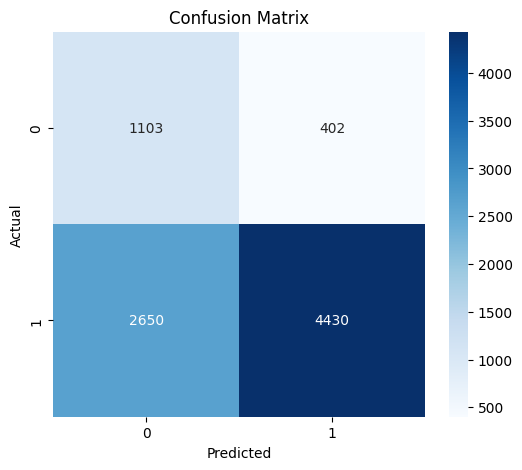

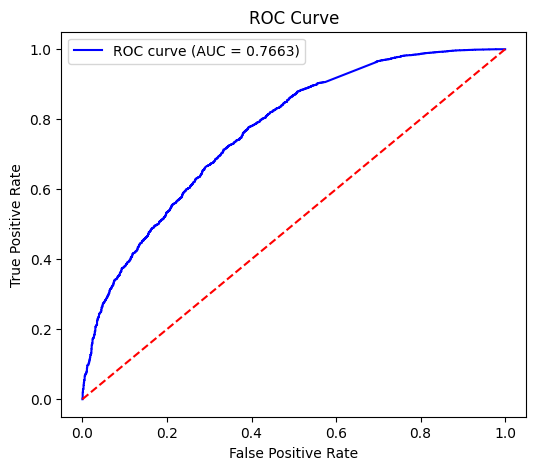

Best Threshold (max F1): 0.23, F1 Score: 0.9159


In [4]:
# =====================================================
# model_evaluation.ipynb
# =====================================================

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import tensorflow as tf

# Load your model (if not already in memory)
# from tensorflow.keras.models import load_model
# model = load_model("ann_model.h5")

# =====================================================
# 1. Predictions
# =====================================================
# Predict probabilities for test set
y_pred_proba = ann_model.predict(xtest).ravel()  # shape (n_samples,)

# Default threshold = 0.5
y_pred = (y_pred_proba >= 0.5).astype(int)

# =====================================================
# 2. Accuracy and F1 metrics
# =====================================================
acc = accuracy_score(ytest, y_pred)
prec = precision_score(ytest, y_pred)
rec = recall_score(ytest, y_pred)
f1 = f1_score(ytest, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")

# =====================================================
# 3. Confusion Matrix
# =====================================================
cm = confusion_matrix(ytest, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =====================================================
# 4. ROC Curve and AUC
# =====================================================
fpr, tpr, thresholds = roc_curve(ytest, y_pred_proba)
roc_auc = roc_auc_score(ytest, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# =====================================================
# 5. Optional: Find best threshold maximizing F1
# =====================================================
best_f1 = 0
best_thresh = 0.5

for t in np.arange(0.0, 1.0, 0.01):
    y_temp = (y_pred_proba >= t).astype(int)
    f1_temp = f1_score(ytest, y_temp)
    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_thresh = t

print(f"Best Threshold (max F1): {best_thresh:.2f}, F1 Score: {best_f1:.4f}")

# Apply best threshold
y_pred_best = (y_pred_proba >= best_thresh).astype(int)
